# Renaissance OCR + LLM Cleanup Pipeline

## Goal

The goal of this project is to process early modern Spanish printed texts using an OCR pipeline and then test whether a multimodal LLM can improve OCR output.

The final workflow is:

PDF -> page images -> OCR with Kraken -> post-processing with Gemini -> evaluation with CER/WER


## What was done

The work was carried out in several stages:

1. Pages were extracted from source PDFs.
2. Double-page spreads were split when needed.
3. Transcript files were converted into clean text files.
4. PAGE XML files were generated with Kraken segmentation and aligned with available transcripts.
5. A line-level dataset was extracted from the cleanest aligned pages.
6. OCR was run on the full page images with a pretrained Kraken historical print model.
7. OCR output was then post-processed with Gemini using both the page image and the OCR text.
8. The raw OCR output and the Gemini-cleaned output were compared against ground truth using CER and WER.


## Important observations

- PAGE/XML alignment and preprocessing did not work perfectly for all pages.
- Historical documents contain irregular layouts, ornamental initials, marginalia, catchwords, old spelling, and OCR-unfriendly typography.
- Because preprocessing and segmentation were not fully reliable on all pages, LLM post-processing was used as a late-stage correction step.
- This matches the project goal well: instead of relying only on OCR, the system uses OCR first and then a cautious LLM cleanup stage.


## Scripts used in the project

- `src/extract_pages.py`  
  Extracts PNG page images from source PDF files.

- `src/split_spreads.py`  
  Detects wide scans and splits them into left/right pages.

- `src/extract_transcripts.py`  
  Converts source transcript documents into clean `.txt` files.

- `src/align_data.py`  
  Runs Kraken segmentation, injects transcript lines into PAGE XML, and creates a clean PAGE/XML subset for training experiments.

- `src/extract_line_dataset.py`  
  Extracts line crops and corresponding `.gt.txt` files from the clean PAGE/XML subset.

- `run_base_ocr.sh`  
  Runs Kraken OCR on page images using the pretrained CATMuS historical print model.

- `run_gemini_cleanup.sh`  
  Sends page image + OCR text to Gemini and returns conservative cleaned text, removed noise, and uncertain cases.

- `src/evaluate_ocr_vs_gemini.py`  
  Computes CER and WER for raw OCR and Gemini-cleaned text against ground truth.


## Fine-tuning experiment

A fine-tuning experiment was also carried out on a small line-level dataset extracted from the cleanest aligned pages.

Main conclusion:

- Fine-tuning was technically successful.
- Validation metrics during training looked promising.
- However, the practical OCR improvement on difficult full-page examples was limited.
- In some cases the pretrained historical model still performed better than the fine-tuned one.

Because of this, the final system relies primarily on the pretrained Kraken historical model plus Gemini post-processing.


## Load evaluation results


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

metrics_dir = Path('outputs/metrics')
csv_path = metrics_dir / 'cer_wer_results.csv'
summary_path = metrics_dir / 'summary.txt'

df = pd.read_csv(csv_path)
summary_text = summary_path.read_text(encoding='utf-8')

print(summary_text)
df.head()

Number of evaluated pages: 16

=== RAW METRICS ===
Average CER OCR    : 0.088775
Average CER Gemini : 0.037222
Average WER OCR    : 0.234301
Average WER Gemini : 0.137667
Pages where Gemini improved CER (raw): 15/16
Pages where Gemini improved WER (raw): 15/16

=== NORMALIZED METRICS ===
Average CER OCR    : 0.079138
Average CER Gemini : 0.030490
Average WER OCR    : 0.208142
Average WER Gemini : 0.120750
Pages where Gemini improved CER (norm): 14/16
Pages where Gemini improved WER (norm): 15/16


,stem,gt_chars,gt_words,cer_ocr_raw,cer_gemini_raw,cer_gain_raw,wer_ocr_raw,wer_gemini_raw,wer_gain_raw,cer_ocr_norm,cer_gemini_norm,cer_gain_norm,wer_ocr_norm,wer_gemini_norm,wer_gain_norm
0,BuendiaInstruccion_page_002_right,620,113,0.053226,0.064516,-0.011290,0.176991,0.212389,-0.035398,0.032520,0.045528,-0.013008,0.115044,0.150442,-0.035398
1,BuendiaInstruccion_page_003_left,889,161,0.041620,0.007874,0.033746,0.161491,0.018634,0.142857,0.030508,0.003390,0.027119,0.130435,0.018634,0.111801
2,BuendiaInstruccion_page_003_right,866,147,0.039261,0.019630,0.019630,0.156463,0.081633,0.074830,0.025552,0.006969,0.018583,0.108844,0.040816,0.068027
3,BuendiaInstruccion_page_004_left,111,19,0.117117,0.054054,0.063063,0.263158,0.210526,0.052632,0.090909,0.027273,0.063636,0.210526,0.157895,0.052632
4,BuendiaInstruccion_page_004_right,974,169,0.083162,0.078029,0.005133,0.242604,0.207101,0.035503,0.071134,0.072165,-0.001031,0.201183,0.195266,0.005917


## Summary table


In [4]:
summary_rows = [
    ['Raw CER', 0.088775, 0.037222],
    ['Raw WER', 0.234301, 0.137667],
    ['Normalized CER', 0.079138, 0.030490],
    ['Normalized WER', 0.208142, 0.120750],
]

summary_df = pd.DataFrame(summary_rows, columns=['Metric', 'OCR', 'Gemini'])
summary_df

,Metric,OCR,Gemini
0,Raw CER,0.088775,0.037222
1,Raw WER,0.234301,0.137667
2,Normalized CER,0.079138,0.030490
3,Normalized WER,0.208142,0.120750


## Plot 1: Average OCR vs Gemini performance


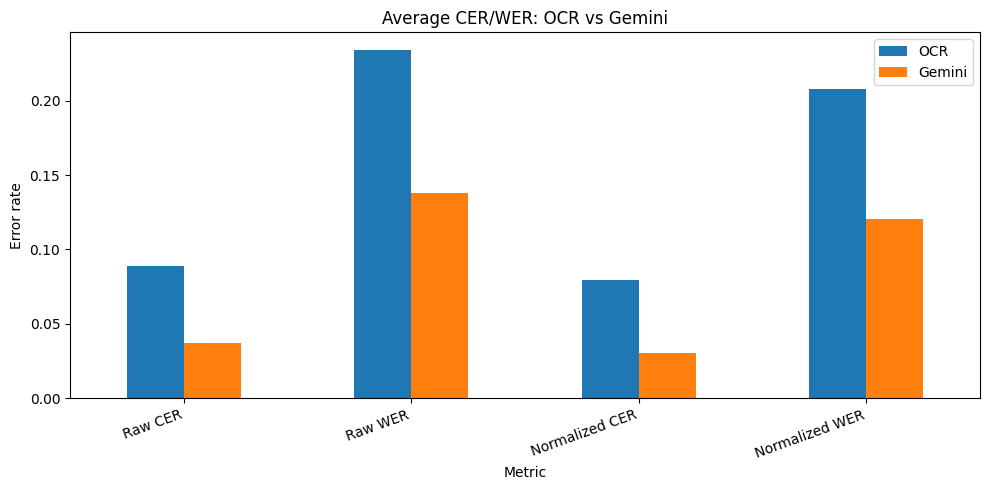

In [5]:
plot_df = summary_df.set_index('Metric')

ax = plot_df.plot(kind='bar', figsize=(10, 5))
ax.set_ylabel('Error rate')
ax.set_title('Average CER/WER: OCR vs Gemini')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Plot 2: Page-level CER improvement


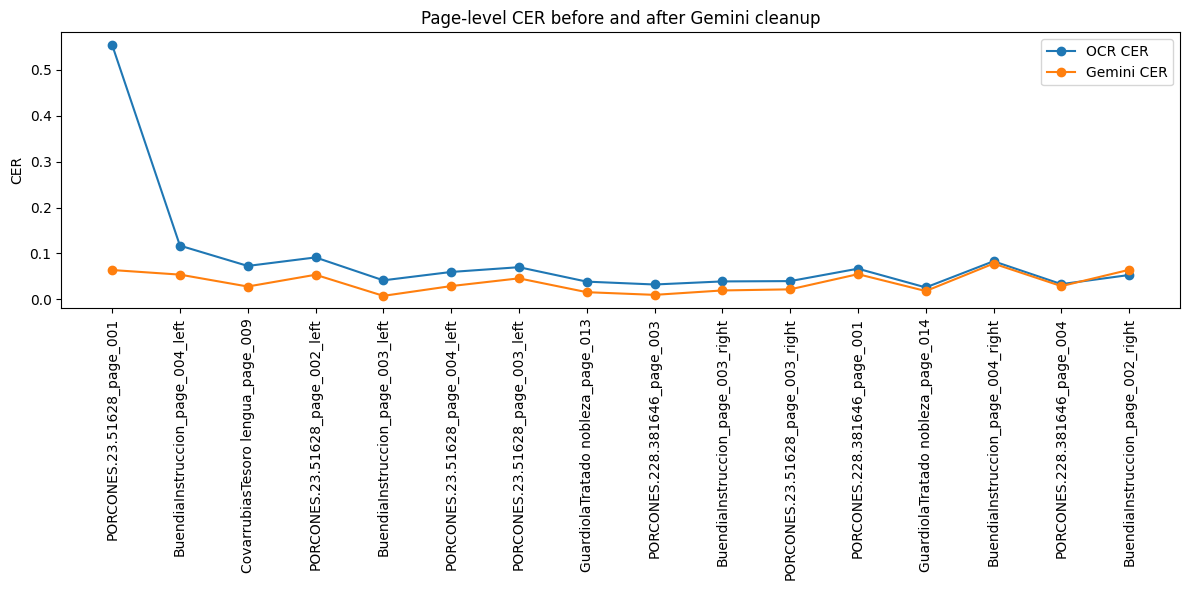

In [7]:
page_plot = df[['stem', 'cer_ocr_raw', 'cer_gemini_raw', 'cer_gain_raw']].copy()
page_plot = page_plot.sort_values('cer_gain_raw', ascending=False)

plt.figure(figsize=(12, 6))
x = range(len(page_plot))
plt.plot(x, page_plot['cer_ocr_raw'].values, marker='o', label='OCR CER')
plt.plot(x, page_plot['cer_gemini_raw'].values, marker='o', label='Gemini CER')
plt.xticks(x, page_plot['stem'].values, rotation=90)
plt.ylabel('CER')
plt.title('Page-level CER before and after Gemini cleanup')
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

The evaluation shows that Gemini post-processing improves OCR quality on most of the evaluated pages.

Key takeaways:

- Gemini reduces both CER and WER compared with raw OCR.
- The improvement is strong both in raw evaluation and in normalized evaluation.
- Most pages benefit from the cleanup stage.
- This suggests that conservative multimodal post-processing is a useful addition to OCR for historical documents.

At the same time, this project also shows an important limitation:

- preprocessing and alignment are difficult on historical material,
- fine-tuning on a small custom dataset does not automatically outperform a strong pretrained historical OCR model,
- therefore the final practical solution is not "train everything from scratch", but rather:

pretrained OCR model + conservative LLM cleanup + quantitative evaluation.
